In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
years = range(2013, 2024)
dfs = []

for year in years:
    temp = pd.read_csv(f"PROV_TYPE_{year}.csv")
    temp['Year'] = year
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

In [4]:
print("Total rows:", df.shape[0])
print("Total unique providers (NPI):", df['Rndrng_NPI'].nunique())


Total rows: 12232194
Total unique providers (NPI): 1825405


In [5]:
# check duplicate NPIs
duplicate_counts = df['Rndrng_NPI'].value_counts()

duplicates = duplicate_counts[duplicate_counts > 1]

print("Number of providers appearing multiple times:", len(duplicates))
print("Maximum number of times a provider appears:", duplicate_counts.max())

Number of providers appearing multiple times: 1638397
Maximum number of times a provider appears: 11


In [6]:
# duplicates across years
duplicate_across_years = (
    df.groupby('Rndrng_NPI')['Year']
      .nunique()
      .sort_values(ascending=False)
)

print(duplicate_across_years.head())

Rndrng_NPI
1003000639    11
1003000704    11
1003000126    11
1003000134    11
1003000142    11
Name: Year, dtype: int64


In [7]:
# duplicates within the same year
within_year_duplicates = (
    df.duplicated(subset=['Rndrng_NPI','Year'])
)

print("Duplicate rows within same provider-year:",
      within_year_duplicates.sum())

Duplicate rows within same provider-year: 0


In [9]:
providers_per_year = (
    df.groupby('Year')['Rndrng_NPI']
      .nunique()
      .sort_index()
)

print(providers_per_year)

Year
2013     956251
2014     986657
2015    1019377
2016    1053958
2017    1088687
2018    1121462
2019    1155870
2020    1161542
2021    1198754
2022    1230293
2023    1259343
Name: Rndrng_NPI, dtype: int64


In [10]:
print("Minimum providers:", providers_per_year.min())
print("Maximum providers:", providers_per_year.max())
print("Average providers per year:", providers_per_year.mean())


Minimum providers: 956251
Maximum providers: 1259343
Average providers per year: 1112017.6363636365


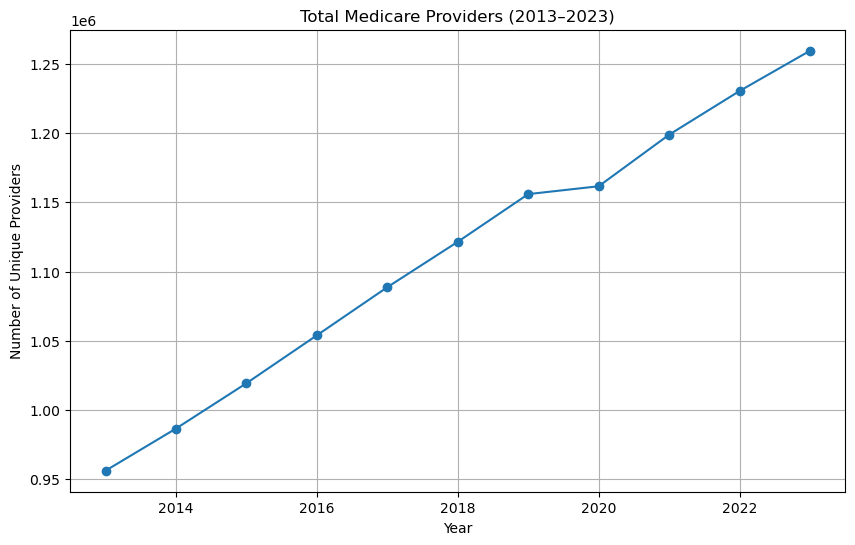

In [16]:
plt.figure(figsize=(10,6))
plt.plot(providers_per_year.index,
         providers_per_year.values,
         marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Unique Providers")
plt.title("Total Medicare Providers (2013–2023)")
plt.grid(True)
plt.show()

Year
2013         NaN
2014    3.179709
2015    3.316249
2016    3.392366
2017    3.295103
2018    3.010507
2019    3.068138
2020    0.490713
2021    3.203672
2022    2.630982
2023    2.361226
Name: Rndrng_NPI, dtype: float64
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


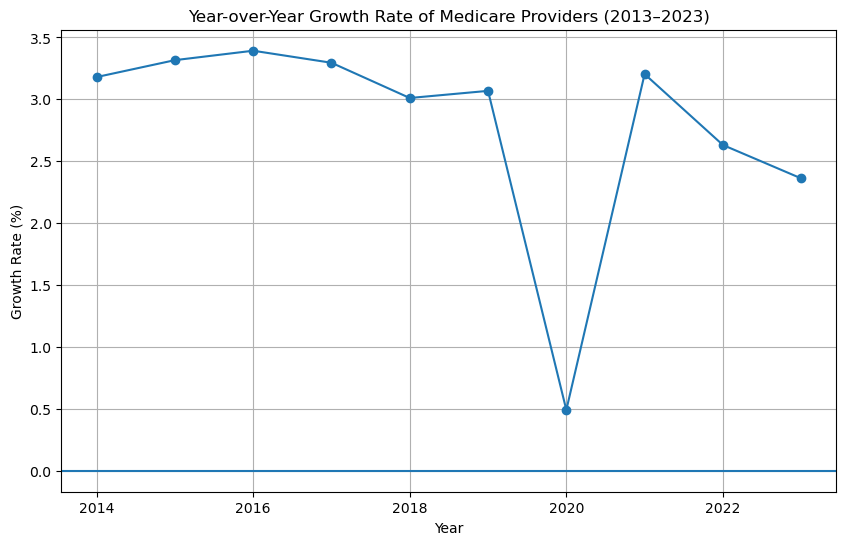

In [15]:
growth_rate = providers_per_year.pct_change() * 100

print(growth_rate)

plt.figure(figsize=(10,6))

plt.plot(growth_rate.index,
         growth_rate.values,
         marker='o')

plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("Year-over-Year Growth Rate of Medicare Providers (2013–2023)")
plt.axhline(0)
plt.grid(True)

plt.show()

In [13]:
start = providers_per_year.iloc[0]
end = providers_per_year.iloc[-1]

overall_growth = ((end - start) / start) * 100

print("Overall Growth from 2013 to 2023:", overall_growth, "%")

Overall Growth from 2013 to 2023: 31.695862278836834 %


In [14]:
df_sorted = df.sort_values('Year')

first_year = (
    df_sorted.groupby('Rndrng_NPI')['Year']
             .min()
)

new_providers_per_year = first_year.value_counts().sort_index()

print(new_providers_per_year)

Year
2013    956251
2014     91122
2015     85708
2016     84025
2017     83154
2018     83243
2019     86078
2020     78975
2021     91506
2022     93621
2023     91722
Name: count, dtype: int64
